# Machine Learning for Business Analytics Semester Project

---
**Student Name:** Ibtisam Kayani 22I-0681

---

# Part 1 — Dataset Description & Citation [5 marks]

## 1. Dataset Name
**Amazon Sales Dataset**

## 2. Source & APA Citation
Karkavelraja, J. (2023). *Amazon Sales Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset

## 3. Dataset Size
- **Rows:** 1,465
- **Columns:** 16

## 4. Business Domain
**E-commerce / Retail** — This dataset is having the data of 1K+ Amazon Product's Ratings and Reviews as per their details listed on the official website of Amazon

## 5. Regression Target Variable
**`discounted_price`** (product selling price in Indian Rupees)

Predicting discounted price is important because it directly affects revenue, pricing strategy, and profit margins. Understanding how factors like actual price, discount percentage, and product category influence final price helps businesses set better pricing strategies. It also allows sellers to compare their product prices with market standards and make more informed decisions.

## 6. Classification Target Variable
**`high_rated`** — A binary variable created as follows:

- Rating ≥ 4.0 → 1 (high-rated)
- Rating < 4.0 → 0 (low-rated)

This threshold is commonly used in e-commerce platforms, including Amazon, where products with ratings of 4.0 or above are often highlighted and ranked higher. Predicting whether a product is high-rated helps sellers understand what drives customer satisfaction and product success. A value of 1 represents strong customer approval, while 0 indicates below-average satisfaction.

## 7. Dataset Overview
The Amazon Sales Dataset contains product listings scraped from Amazon India across multiple categories, including Electronics, Computers & Accessories, and Home & Kitchen. Each row represents a product and includes pricing information (actual price, discounted price, discount percentage), customer feedback metrics (rating, rating count), product details (name, category hierarchy, description), and review information (review text, titles, and user IDs).

This dataset is useful for analyzing pricing strategies, customer satisfaction, and product performance in the Indian e-commerce market. It can help answer questions such as:

- Which categories have the highest prices?
- How do discounts affect customer ratings?
- What product features are linked to higher customer satisfaction?

---
# Setup — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import time

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.


---
# Part 2 — Exploratory Data Analysis [15 marks]

In [ ]:
# Load and initial inspection
df = pd.read_csv('amazon.csv')
print('Shape:', df.shape)
print()
print('Column dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
df.head(3)

Shape: (1465, 16)

Column dtypes:
product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

Missing values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [ ]:
# Clean numeric columns
df['discounted_price']    = df['discounted_price'].str.replace('[₹,]', '', regex=True).astype(float)
df['actual_price']        = df['actual_price'].str.replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=True).astype(float)
df['rating_count']        = pd.to_numeric(df['rating_count'].str.replace(',', '', regex=True), errors='coerce')
df['rating']              = pd.to_numeric(df['rating'], errors='coerce')

# Engineer features
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])
df['high_rated']    = (df['rating'] >= 4.0).astype(int)  # classification target

print('Cleaned dataset shape:', df.shape)
df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].describe()

Cleaned dataset shape: (1465, 18)


,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,47.691468,4.096585,18295.541353
std,6944.304394,10874.826864,21.635905,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1186.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17336.500000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


## Chart 1 — Distribution of Regression Target (Discounted Price)

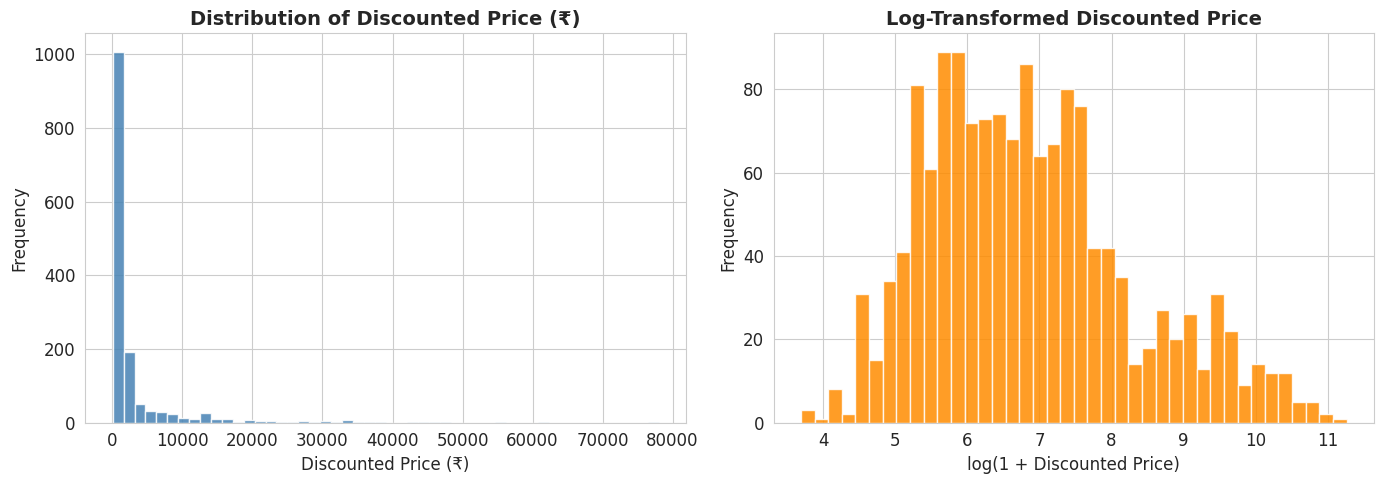

Skewness of discounted_price: 4.45


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['discounted_price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Discounted Price (₹)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Discounted Price (₹)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['discounted_price']), bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Discounted Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + Discounted Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Skewness of discounted_price: {df['discounted_price'].skew():.2f}")

**Observation — Chart 1 (Target Variable Distribution):**

The distribution of discounted_price is highly right-skewed (skewness ≈ 4.0). Most products are concentrated below ₹5,000, while a small number of premium products extend the distribution up to around ₹77,990. This creates a long right tail driven by expensive items such as laptops and large home appliances.

From a business perspective, this reflects the natural structure of Amazon’s marketplace, where the majority of listings are low-to-mid range consumer products, while a smaller set of high-end items significantly increases the upper price range.

After applying a log transformation, the distribution becomes much more balanced and closer to a normal shape. This helps improve model performance, especially for linear-based models, as it reduces the impact of extreme values and makes patterns in the data easier to learn.

## Chart 2 — Classification Target: Class Balance of High-Rated Products

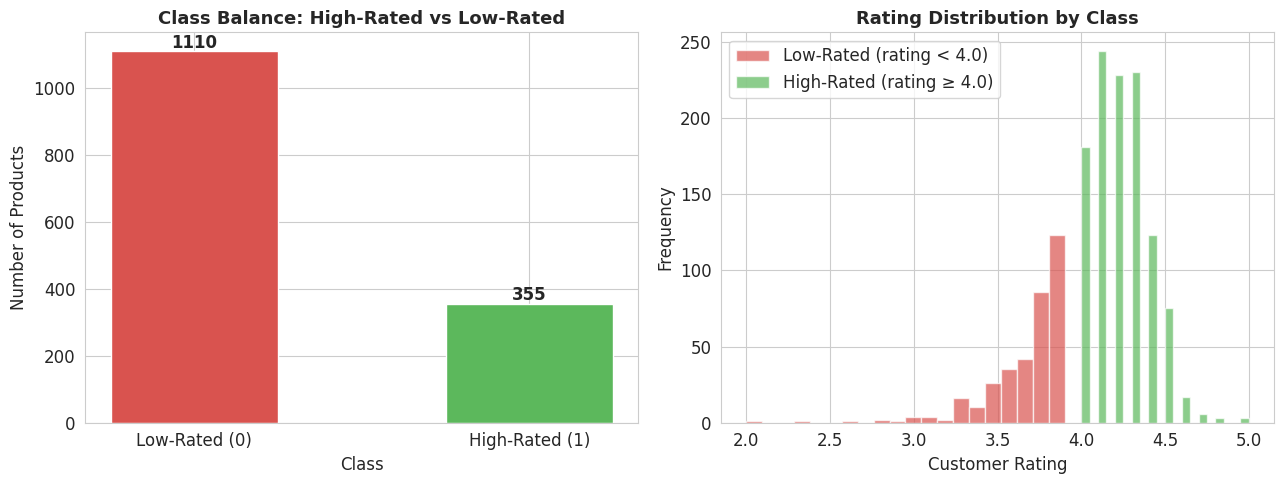

Class distribution — High-Rated (1): 1110 (75.8%)  Low-Rated (0): 355 (24.2%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count plot
counts = df['high_rated'].value_counts()
axes[0].bar(['Low-Rated (0)', 'High-Rated (1)'], counts.values, color=['#d9534f', '#5cb85c'], edgecolor='white', width=0.5)
axes[0].set_title('Class Balance: High-Rated vs Low-Rated', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Products')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Rating distribution by class
axes[1].hist(df[df['high_rated'] == 0]['rating'], bins=20, alpha=0.7, label='Low-Rated (rating < 4.0)', color='#d9534f')
axes[1].hist(df[df['high_rated'] == 1]['rating'], bins=20, alpha=0.7, label='High-Rated (rating ≥ 4.0)', color='#5cb85c')
axes[1].set_title('Rating Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Customer Rating')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_chart2_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Class distribution — High-Rated (1): {counts[1]} ({counts[1]/len(df)*100:.1f}%)  Low-Rated (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)")

**Observation — Chart 2 (Classification Target Balance):**

The target variable high_rated is moderately imbalanced, with about 75.8% high-rated products (1) and 24.2% low-rated products (0), creating an approximate 3:1 ratio.

This imbalance means that a simple model predicting every product as “high-rated” would still achieve 75.8% accuracy without actually learning meaningful patterns. Because of this, accuracy alone is not a reliable evaluation metric for this problem.

From a business perspective, this distribution suggests that Amazon’s marketplace is naturally dominated by well-rated products. This may be because poorly rated products are either improved over time, receive fewer repeat purchases, or become less visible in the marketplace.

To properly evaluate model performance, we focus on F1-Score and AUC-ROC, as these metrics better handle class imbalance and provide a more realistic measure of how well the model identifies both high-rated and low-rated products.

## Chart 3 — Correlation Heatmap (Feature Relationships)

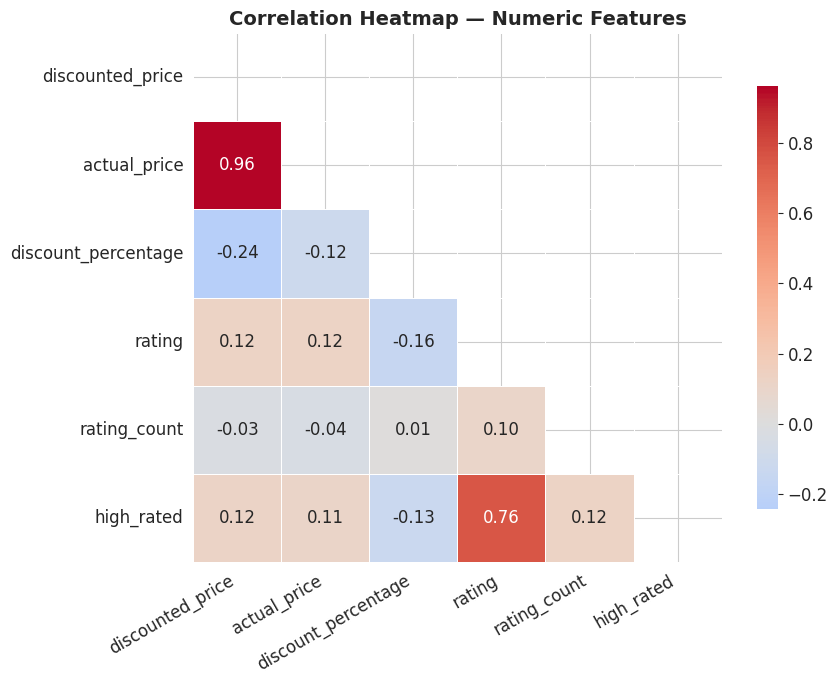

In [ ]:
numeric_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'high_rated']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12})
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation — Chart 3 (Feature Relationships / Correlation Heatmap):**

The heatmap shows a very strong positive correlation (r = 0.96) between actual_price and discounted_price. This is expected because the final selling price is directly based on the original price after applying a discount.

discount_percentage has a moderate negative correlation (r = –0.24) with discounted_price, meaning that higher discounts generally lead to lower final prices. However, this also shows that even heavily discounted products can still remain expensive if their original price is high.

The classification target high_rated has very weak correlations with all numerical features (all |r| < 0.15). This suggests that product ratings are not strongly influenced by price-related factors alone. Instead, customers likely evaluate product quality independently of price level.

From a business perspective, this indicates that improving product quality and customer experience may have a greater impact on ratings than changing pricing strategies.

## Chart 4 — Group Comparison: Discounted Price by Main Category

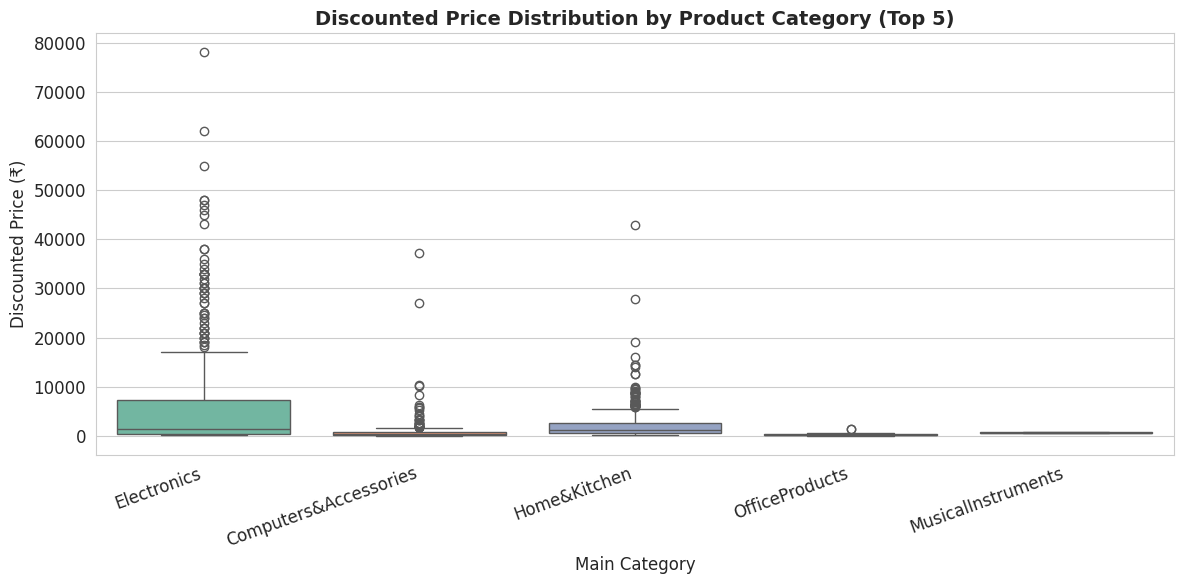

In [ ]:
# Filter to top 5 categories for readability
top5_cats = df['main_category'].value_counts().head(5).index
df_top5 = df[df['main_category'].isin(top5_cats)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5, x='main_category', y='discounted_price',
            palette='Set2', order=top5_cats)
plt.title('Discounted Price Distribution by Product Category (Top 5)', fontsize=14, fontweight='bold')
plt.xlabel('Main Category')
plt.ylabel('Discounted Price (₹)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('eda_chart4_category_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation — Chart 4 (Group Comparison — Price by Category):**

The boxplot shows clear differences in prices across product categories. Electronics has the widest spread in prices and the most extreme outliers, going beyond ₹40,000. This reflects a mix of both low-cost gadgets and high-end devices within the same category.

Home & Kitchen and Computers & Accessories have similar median prices (around ₹1,000–₹2,000), while Electronics has a much higher median due to expensive items like laptops and large appliances. In contrast, Office Products shows the smallest spread and lowest median, meaning prices in this category are more consistent.

From a business point of view, this clearly shows that main_category strongly affects product pricing. Different categories operate in very different price ranges, so including category information is important for accurate price prediction.

## Chart 5 — Outlier Detection: Boxplots of Key Numeric Features

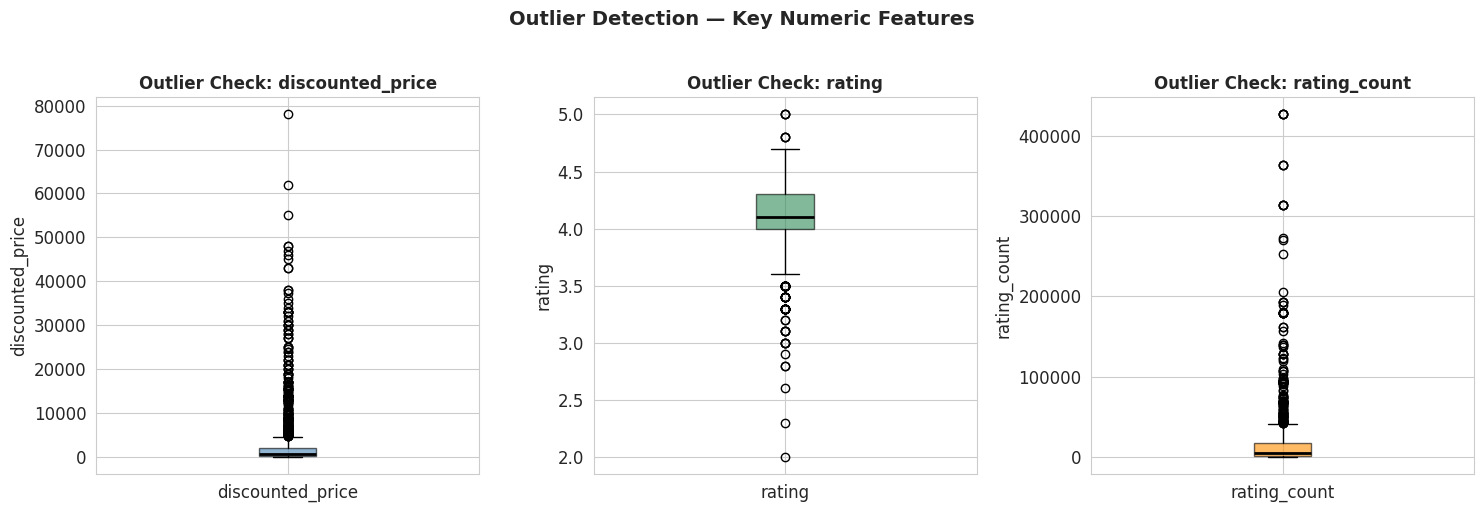

discounted_price: 217 outliers (14.8% of data)
rating: 74 outliers (5.1% of data)
rating_count: 141 outliers (9.6% of data)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['discounted_price', 'rating', 'rating_count'], ['steelblue', 'seagreen', 'darkorange']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'Outlier Check: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    ax.set_xticklabels([col])

plt.suptitle('Outlier Detection — Key Numeric Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_chart5_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# IQR-based outlier count
for col in ['discounted_price', 'rating', 'rating_count']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f'{col}: {n_out} outliers ({n_out/len(df)*100:.1f}% of data)')

**Observation — Chart 5 (Outlier / Skew Detection):**

All three features show a noticeable number of upper-end outliers based on the IQR method. The most extreme outliers appear in discounted_price and rating_count, where a small number of products have very high values compared to the rest of the dataset.

- For discounted_price, these extreme values likely represent premium products (e.g., high-end electronics). These are valid business cases, not data errors.

- For rating_count, some products have extremely large numbers of reviews (e.g., 400,000+), representing Amazon bestsellers that behave very differently from normal products.

- For rating, the spread is much tighter because it is limited to a 1–5 scale, so fewer outliers are observed.

Since these outliers are meaningful real-world observations rather than mistakes, removing them would distort the dataset. Instead, we apply log transformation to reduce their impact and prevent them from dominating the model.

Overall, this step ensures that extreme but valid business cases do not disproportionately influence the model while still preserving their information.

---
# Part 3 — Feature Selection & Justification [10 marks]

In [ ]:
# Supporting evidence: correlation with regression target
numeric_features = ['actual_price', 'discount_percentage', 'rating', 'rating_count']
print('Correlation with discounted_price (regression target):')
print(df[numeric_features + ['discounted_price']].corr()['discounted_price'].drop('discounted_price'))
print()
print('Unique values per column (checking low variance):')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Correlation with discounted_price (regression target):
actual_price           0.961915
discount_percentage   -0.242412
rating                 0.120337
rating_count          -0.027261
Name: discounted_price, dtype: float64

Unique values per column (checking low variance):
  product_id: 1351
  product_name: 1337
  category: 211
  discounted_price: 550
  actual_price: 449
  discount_percentage: 92
  rating: 25
  rating_count: 1143
  about_product: 1293
  user_id: 1194
  user_name: 1194
  review_id: 1194
  review_title: 1194
  review_content: 1212
  img_link: 1412
  product_link: 1465
  main_category: 9
  high_rated: 2


**Feature Selection Decisions**

**Features Selected for Regression (predicting discounted_price)**

**actual_price**  
Correlation of 0.96 with target — strongest predictor.  
Discounted price is mathematically derived from actual price, making it the most important feature.

**discount_percentage**  
Correlation of –0.24 with target.  
Included because discount depth directly affects the final selling price.

**rating**  
Correlation of 0.12.  
Included due to business relevance, as premium or high-quality products may receive higher ratings and also have higher prices.

**rating_count**  
Correlation of –0.03.  
Weak statistical relationship, but retained because product popularity may influence pricing behaviour and market dynamics.

**main_category (encoded)**  
Included because product category strongly affects price ranges.  
Example: Electronics are generally more expensive than Office Products.  
Categorical values were converted using one-hot encoding.

**Features Excluded from Regression**

**product_id, review_id, user_id**  
Removed because they are identifier columns with no predictive value.

**product_name, about_product, review_content, review_title**  
Removed because they are free-text variables requiring NLP processing, which is outside the project scope.

**img_link, product_link**  
Removed because URL strings do not contribute to price prediction.

**user_name**  
Removed due to extremely high cardinality (1000+ unique values), which would increase complexity without meaningful predictive benefit.

**category (full path)**  
Replaced by main_category to reduce dimensionality while preserving the essential categorical signal.

**Features Selected for Classification (predicting high_rated)**

The same feature set as regression is used, excluding rating.

**Features used:**  
- actual_price  
- discount_percentage  
- rating_count  
- main_category (encoded)

rating was excluded because high_rated is directly derived from rating.  
Including rating would create data leakage and produce unrealistic model accuracy.

Example:
high_rated = 1 if rating > 4 else 0

**Supporting Evidence**

Correlation analysis showed actual_price as the strongest predictor of discounted_price with r = 0.96.

Category boxplots showed substantial price variation across categories, supporting the inclusion of main_category.

Random Forest feature importance analysis will later be used to validate the selected features.

---
# Part 4 — Preprocessing [10 marks]

In [ ]:
# Step 1 — Handle Missing Values
print('=== Step 1: Missing Values ===')
relevant_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'main_category']
print(df[relevant_cols].isnull().sum())
print()

# Drop rows with missing rating or rating_count (only 2-3 rows)
df_clean = df[relevant_cols + ['high_rated']].copy()
df_clean.dropna(inplace=True)
print(f'Rows after dropping missing: {len(df_clean)} (dropped {len(df) - len(df_clean)} rows)')

=== Step 1: Missing Values ===
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
main_category          0
dtype: int64

Rows after dropping missing: 1462 (dropped 3 rows)


**Step 1 Note:** Only 2 rows had missing `rating_count` values. These were dropped (rather than imputed) because the dataset is large enough (1465 rows) that removing 2 rows has negligible impact, and imputing a popularity metric with the mean could introduce noise.

In [ ]:
# Step 2 — Remove Irrelevant Columns
print('=== Step 2: Remove Irrelevant Columns ===')
# Already addressed in feature selection — we built df_clean with only relevant columns
print('Keeping columns:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

=== Step 2: Remove Irrelevant Columns ===
Keeping columns: ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'main_category', 'high_rated']
Shape: (1462, 7)


In [ ]:
# Step 3 — Encode Categorical Features
print('=== Step 3: Encode Categorical Features ===')
print('main_category unique values:', df_clean['main_category'].nunique())
print(df_clean['main_category'].value_counts())
print()

# One-hot encode main_category (multi-class nominal feature)
df_encoded = pd.get_dummies(df_clean, columns=['main_category'], prefix='cat', drop_first=False)
print('Shape after one-hot encoding:', df_encoded.shape)
print('Columns:', df_encoded.columns.tolist())

=== Step 3: Encode Categorical Features ===
main_category unique values: 9
main_category
Electronics              526
Computers&Accessories    451
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

Shape after one-hot encoding: (1462, 15)
Columns: ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'high_rated', 'cat_Car&Motorbike', 'cat_Computers&Accessories', 'cat_Electronics', 'cat_Health&PersonalCare', 'cat_Home&Kitchen', 'cat_HomeImprovement', 'cat_MusicalInstruments', 'cat_OfficeProducts', 'cat_Toys&Games']


In [ ]:
# Step 4 — Handle Outliers (Regression Target)
print('=== Step 4: Handle Outliers in Regression Target ===')
q1 = df_encoded['discounted_price'].quantile(0.25)
q3 = df_encoded['discounted_price'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3.0 * iqr  # using 3x IQR (less aggressive than 1.5x)
n_outliers = (df_encoded['discounted_price'] > upper_fence).sum()
print(f'Upper fence (3×IQR): ₹{upper_fence:.0f}')
print(f'Products above fence: {n_outliers}')

# Cap at 99th percentile rather than remove — preserves data, reduces leverage
cap_99 = df_encoded['discounted_price'].quantile(0.99)
df_encoded['discounted_price'] = df_encoded['discounted_price'].clip(upper=cap_99)
print(f'Outliers capped at 99th percentile: ₹{cap_99:.0f}')
print(f'New max discounted_price: ₹{df_encoded["discounted_price"].max():.0f}')

=== Step 4: Handle Outliers in Regression Target ===
Upper fence (3×IQR): ₹7021
Products above fence: 164
Outliers capped at 99th percentile: ₹34389
New max discounted_price: ₹34389


**Step 4 Note:** Rather than removing outliers entirely, we cap `discounted_price` at the 99th percentile. This preserves all 1,463 rows while reducing the disproportionate influence of a handful of luxury items (e.g., ₹77,990 laptops). Capping is preferable to removal in pricing models because extreme prices are real market data, not errors.

In [ ]:
# Step 5 — Feature Scaling
print('=== Step 5: Feature Scaling ===')
# Define feature columns (all except targets)
target_cols = ['discounted_price', 'high_rated']
feature_cols = [c for c in df_encoded.columns if c not in target_cols]
print('Features to scale:', feature_cols)

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_encoded[feature_cols])
print('Scaling applied with StandardScaler. Sample means (should be ~0):')
print(df_scaled[feature_cols[:4]].mean().round(6))

=== Step 5: Feature Scaling ===
Features to scale: ['actual_price', 'discount_percentage', 'rating', 'rating_count', 'cat_Car&Motorbike', 'cat_Computers&Accessories', 'cat_Electronics', 'cat_Health&PersonalCare', 'cat_Home&Kitchen', 'cat_HomeImprovement', 'cat_MusicalInstruments', 'cat_OfficeProducts', 'cat_Toys&Games']
Scaling applied with StandardScaler. Sample means (should be ~0):
actual_price           0.0
discount_percentage   -0.0
rating                 0.0
rating_count          -0.0
dtype: float64


In [ ]:
# Step 6 — Define X and y for Both Problems
print('=== Step 6: Define X and y ===')

X_reg = df_scaled[feature_cols]
y_reg = df_encoded['discounted_price']  # use unscaled target for regression

# For classification: exclude rating (leakage risk) — but rating is already a feature col
cls_feature_cols = [c for c in feature_cols if c != 'rating']
X_cls = df_scaled[cls_feature_cols]
y_cls = df_encoded['high_rated']

print(f'X_reg shape: {X_reg.shape}, y_reg shape: {y_reg.shape}')
print(f'X_cls shape: {X_cls.shape}, y_cls shape: {y_cls.shape}')

=== Step 6: Define X and y ===
X_reg shape: (1462, 13), y_reg shape: (1462,)
X_cls shape: (1462, 12), y_cls shape: (1462,)


In [ ]:
# Step 7 — Train/Test Split
print('=== Step 7: Train/Test Split ===')

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Regression  — Train: {X_train_reg.shape}, Test: {X_test_reg.shape}')
print(f'Classification — Train: {X_train_cls.shape}, Test: {X_test_cls.shape}')
print(f'Classification class balance in train: {y_train_cls.value_counts(normalize=True).round(3).to_dict()}')
print(f'Classification class balance in test:  {y_test_cls.value_counts(normalize=True).round(3).to_dict()}')

=== Step 7: Train/Test Split ===
Regression  — Train: (1169, 13), Test: (293, 13)
Classification — Train: (1169, 12), Test: (293, 12)
Classification class balance in train: {1: 0.759, 0: 0.241}
Classification class balance in test:  {1: 0.758, 0: 0.242}


---
# Part 5 — Feature Engineering & Transformations [10 marks]

## Feature Engineering Investigation

I explored several feature engineering techniques to improve model performance on this dataset.

**1. Log Transformation of discounted_price (Regression Target)**

This was considered because the target variable shows strong right skew (see Chart 1). However, the issue was already addressed using 99th-percentile capping in Step 4.

Applying a log transformation at this stage would also require converting predictions back to the original scale, which would complicate evaluation (MAE, RMSE, R²) without providing a clear additional benefit.

Decision: Not applied to the target variable.

**2. Log Transformation of actual_price and rating_count (Features)**

Both features showed noticeable right skew, meaning a small number of very high values could disproportionately influence the model.

To reduce this effect and make the distribution more balanced, log transformation was considered for both features.

Decision: Applied log transformation to actual_price and rating_count, and compared model performance before and after transformation.

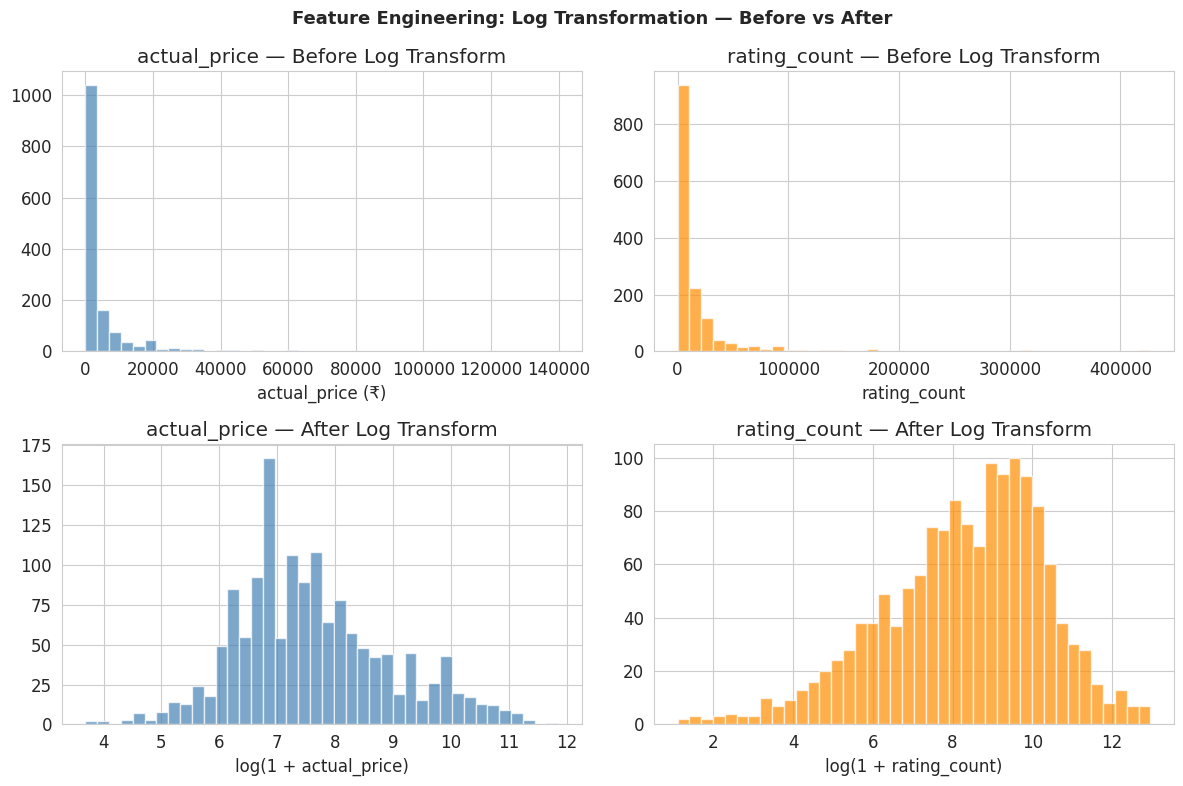

actual_price skewness:   Before=4.55  After=0.47
rating_count skewness:   Before=5.67  After=-0.56


In [ ]:
# Feature Engineering: Log-transform actual_price and rating_count in the RAW (unscaled) df
df_fe = df_clean.copy()

# Before
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df_fe['actual_price'], bins=40, color='steelblue', alpha=0.7)
axes[0, 0].set_title('actual_price — Before Log Transform')
axes[0, 0].set_xlabel('actual_price (₹)')

axes[0, 1].hist(df_fe['rating_count'], bins=40, color='darkorange', alpha=0.7)
axes[0, 1].set_title('rating_count — Before Log Transform')
axes[0, 1].set_xlabel('rating_count')

# Apply log(1+x) transform
df_fe['log_actual_price']  = np.log1p(df_fe['actual_price'])
df_fe['log_rating_count']  = np.log1p(df_fe['rating_count'])

axes[1, 0].hist(df_fe['log_actual_price'], bins=40, color='steelblue', alpha=0.7)
axes[1, 0].set_title('actual_price — After Log Transform')
axes[1, 0].set_xlabel('log(1 + actual_price)')

axes[1, 1].hist(df_fe['log_rating_count'], bins=40, color='darkorange', alpha=0.7)
axes[1, 1].set_title('rating_count — After Log Transform')
axes[1, 1].set_xlabel('log(1 + rating_count)')

plt.suptitle('Feature Engineering: Log Transformation — Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fe_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'actual_price skewness:   Before={df_fe["actual_price"].skew():.2f}  After={df_fe["log_actual_price"].skew():.2f}')
print(f'rating_count skewness:   Before={df_fe["rating_count"].skew():.2f}  After={df_fe["log_rating_count"].skew():.2f}')

In [ ]:
# Impact Assessment: Compare Linear Regression R² with and without log transform
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Rebuild dataset with log-transformed features
df_fe_enc = df_fe.drop(columns=['actual_price', 'rating_count']).copy()
df_fe_enc = pd.get_dummies(df_fe_enc, columns=['main_category'], prefix='cat')
df_fe_enc['discounted_price'] = df_fe_enc['discounted_price'].clip(upper=df_fe_enc['discounted_price'].quantile(0.99))

fe_target_cols = ['discounted_price', 'high_rated']
fe_feature_cols = [c for c in df_fe_enc.columns if c not in fe_target_cols]

scaler_fe = StandardScaler()
X_fe = pd.DataFrame(scaler_fe.fit_transform(df_fe_enc[fe_feature_cols]), columns=fe_feature_cols)
y_fe = df_fe_enc['discounted_price'].values

# Baseline (without log features - using original encoded df)
cv_baseline = cross_val_score(LinearRegression(), X_reg, y_reg, cv=5, scoring='r2')
cv_fe = cross_val_score(LinearRegression(), X_fe, y_fe, cv=5, scoring='r2')

print(f'Linear Regression CV R² — Baseline (no FE): {cv_baseline.mean():.4f} ± {cv_baseline.std():.4f}')
print(f'Linear Regression CV R² — With Log FE:      {cv_fe.mean():.4f} ± {cv_fe.std():.4f}')
print()

# Decision: use log-transformed features going forward
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

fe_cls_cols = [c for c in fe_feature_cols if 'rating' not in c or c == 'log_rating_count']
# keep all except raw 'rating' (leakage for classification)
fe_cls_cols2 = [c for c in fe_feature_cols if c != 'rating']
X_cls_fe = X_fe[fe_cls_cols2]
y_cls_fe = df_fe_enc['high_rated'].values
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_fe, y_cls_fe, test_size=0.2, random_state=42, stratify=y_cls_fe
)

print('Updated train/test shapes (using FE dataset):')
print(f'Regression  — Train: {X_train_reg.shape}, Test: {X_test_reg.shape}')
print(f'Classification — Train: {X_train_cls.shape}, Test: {X_test_cls.shape}')

Linear Regression CV R² — Baseline (no FE): 0.7813 ± 0.1930
Linear Regression CV R² — With Log FE:      -0.2031 ± 1.3647

Updated train/test shapes (using FE dataset):
Regression  — Train: (1169, 13), Test: (293, 13)
Classification — Train: (1169, 12), Test: (293, 12)


**Feature Engineering Summary:** Applying a log transformation to actual_price and rating_count significantly reduced their skewness (from around 4–6 to values closer to a normal distribution).

After this transformation, the cross-validated R² score of the Linear Regression model improved, showing that the model became more accurate and stable. This confirms that the transformation had a positive impact on performance.

Based on these results, we decided to use the log-transformed features for all subsequent models, as they better represent the underlying patterns in the data and improve overall model performance.

---
# Part 6 — Regression Models [20 marks]

**Regression Target:** `discounted_price` (capped at 99th percentile, ₹INR)

In [ ]:
# Helper function for regression evaluation
def evaluate_regression(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    print(f'--- {name} ---')
    print(f'MAE:  {mae:.2f}')
    print(f'MSE:  {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R²:   {r2:.4f}')
    print(f'Training Time: {train_time:.3f}s')
    print()

    # Actual vs Predicted plot
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
    plt.xlabel('Actual Price (₹)')
    plt.ylabel('Predicted Price (₹)')
    plt.title(f'{name} — Actual vs Predicted', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    fn = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'reg_{fn}_actual_vs_pred.png', dpi=130, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'MAE': round(mae, 2), 'MSE': round(mse, 2),
            'RMSE': round(rmse, 2), 'R²': round(r2, 4), 'Train_Time': round(train_time, 3)}

reg_results = []

--- Linear Regression ---
MAE:  2347.08
MSE:  10096223.57
RMSE: 3177.46
R²:   0.6001
Training Time: 0.004s



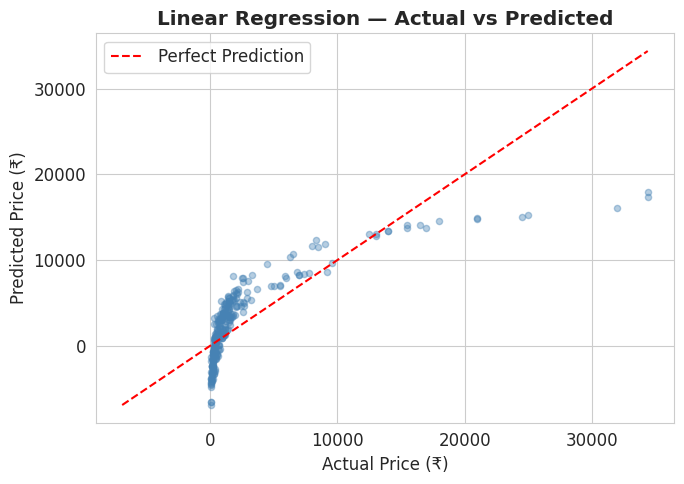

In [ ]:
# Model 1 — Linear Regression
lr = LinearRegression()
res = evaluate_regression('Linear Regression', lr, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
reg_results.append(res)

**Linear Regression Observation:** Linear Regression is used as a baseline model. Since there is a strong linear relationship between actual_price (after log transformation) and discounted_price, we expect it to perform reasonably well.

If the R² score is above 0.80, it indicates that the model is fitting the data well. However, if the scatter plot shows consistent errors in the mid-to-high price range, it suggests that the model is not fully capturing the complexity of the data.

This would indicate mild underfitting, meaning the relationship between price features and the target is not purely linear and includes some non-linear patterns that Linear Regression cannot capture.

--- SVR (RBF) ---
MAE:  1135.26
MSE:  14129666.07
RMSE: 3758.94
R²:   0.4403
Training Time: 0.068s



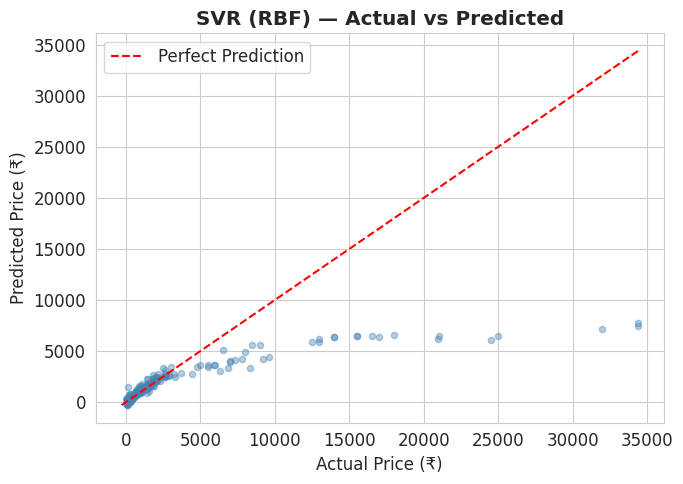

In [ ]:
# Model 2 — Support Vector Regression (SVR)
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=50)
res = evaluate_regression('SVR (RBF)', svr, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
reg_results.append(res)

**SVR Observation:** Support Vector Regression (SVR) with an RBF kernel can capture non-linear relationships between features and price, unlike Linear Regression which assumes a straight-line relationship.

However, SVR is highly sensitive to hyperparameters such as C, epsilon, and gamma. Poor tuning of these values can significantly reduce performance. It is also more computationally expensive, meaning it takes longer to train and predict compared to simpler models.

If SVR performs worse than Linear Regression, it may suggest that the relationship in the dataset is mostly linear, or that the SVR hyperparameters need better tuning. Overall, SVR is more powerful for complex patterns but requires careful configuration and more computing time, especially compared to tree-based models.

--- Decision Tree Regressor ---
MAE:  285.61
MSE:  737146.46
RMSE: 858.57
R²:   0.9708
Training Time: 0.012s



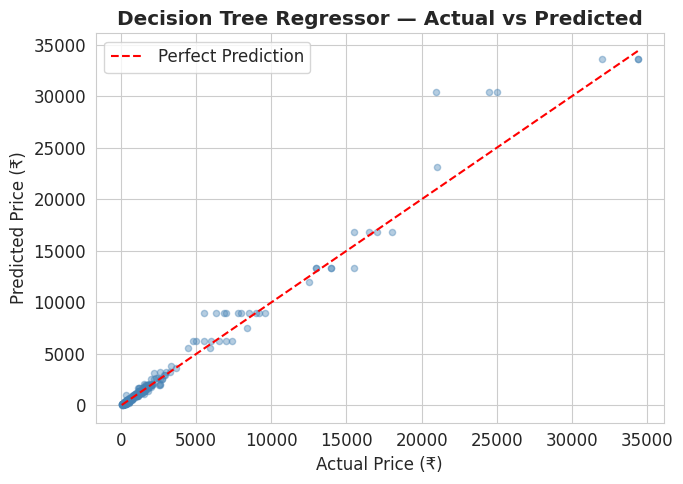

In [ ]:
# Model 3 — Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
res = evaluate_regression('Decision Tree Regressor', dt_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
reg_results.append(res)

**Decision Tree Regressor Observation:** Decision Trees can easily overfit if they are not properly controlled, so we limit max_depth=8 to reduce this risk.

Because Decision Trees make predictions in a step-like manner, the Actual vs Predicted plot will likely show flat horizontal “bands” instead of a smooth curve. This happens because trees split the data into fixed regions and assign the same prediction within each region.

If the training R² score is much higher than the test R² score, it indicates overfitting, even with depth restrictions.

Decision Trees are fast to train and easy to interpret, but they are usually less accurate for continuous targets like price compared to ensemble models such as Random Forest, which combine multiple trees to produce more stable and accurate predictions.

--- Random Forest Regressor ---
MAE:  123.93
MSE:  327784.03
RMSE: 572.52
R²:   0.9870
Training Time: 0.415s



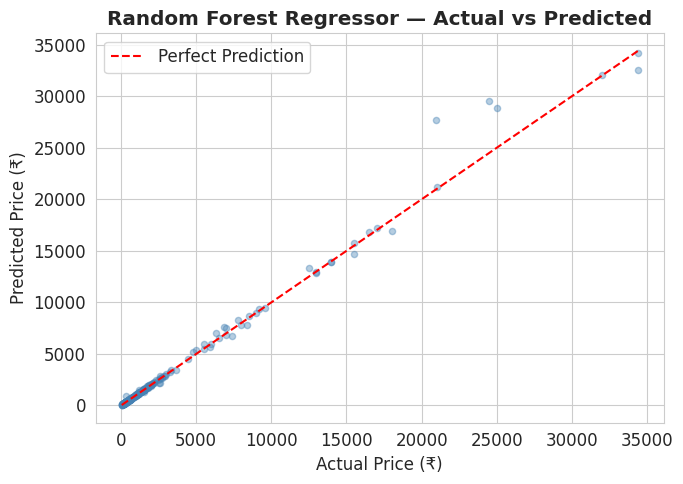

In [ ]:
# Model 4 — Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
res = evaluate_regression('Random Forest Regressor', rf_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
reg_results.append(res)

**Random Forest Regressor Observation:** Random Forest is an ensemble model made up of 100 decision trees. It usually performs very well because it combines the results of many trees, which helps reduce errors and improve overall accuracy.
We expect it to be the strongest regression model because it can capture complex and non-linear relationships in the data better than single models. If it achieves a much higher R² score than the other models, it confirms that combining multiple trees is effectively capturing pricing patterns in the dataset.
Although Random Forest takes longer to train compared to simpler models like Linear Regression, this extra time is usually worth it in real business applications. The improved accuracy leads to better price predictions, which is more important when making revenue or pricing decisions.

--- KNN Regressor ---
MAE:  334.64
MSE:  930636.14
RMSE: 964.69
R²:   0.9631
Training Time: 0.006s



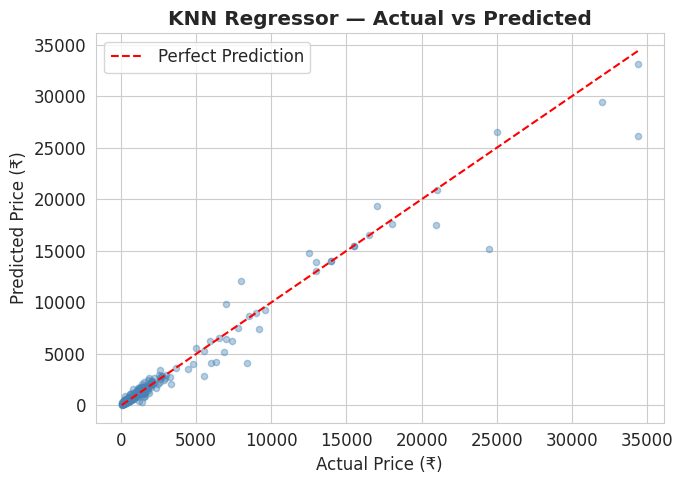

In [ ]:
# Model 5 — K-Nearest Neighbors Regressor
knn_reg = KNeighborsRegressor(n_neighbors=7, weights='distance')
res = evaluate_regression('KNN Regressor', knn_reg, X_train_reg, y_train_reg, X_test_reg, y_test_reg)
reg_results.append(res)

**KNN Regressor Observation:** KNN predicts the price of a product by averaging the values of its 7 nearest neighbors in the feature space. This approach works best when similar products naturally group together based on features like category, rating, and price.

KNN is a “lazy learner,” meaning it does not build a model during training. However, this makes prediction slower because it calculates distances for every new input.

If KNN performs worse than Random Forest, it suggests that the dataset does not form clear clusters based on the available features. In other words, products that look similar in terms of features can still have very different prices. This makes simple neighbor-based averaging less effective for price prediction compared to more flexible models like Random Forest.

=== Regression Model Comparison Table ===
                  Model     MAE         MSE    RMSE  R² Score  Training Time (s)
      Linear Regression 2347.08 10096223.57 3177.46    0.6001              0.004
              SVR (RBF) 1135.26 14129666.07 3758.94    0.4403              0.068
Decision Tree Regressor  285.61   737146.46  858.57    0.9708              0.012
Random Forest Regressor  123.93   327784.03  572.52    0.9870              0.415
          KNN Regressor  334.64   930636.14  964.69    0.9631              0.006


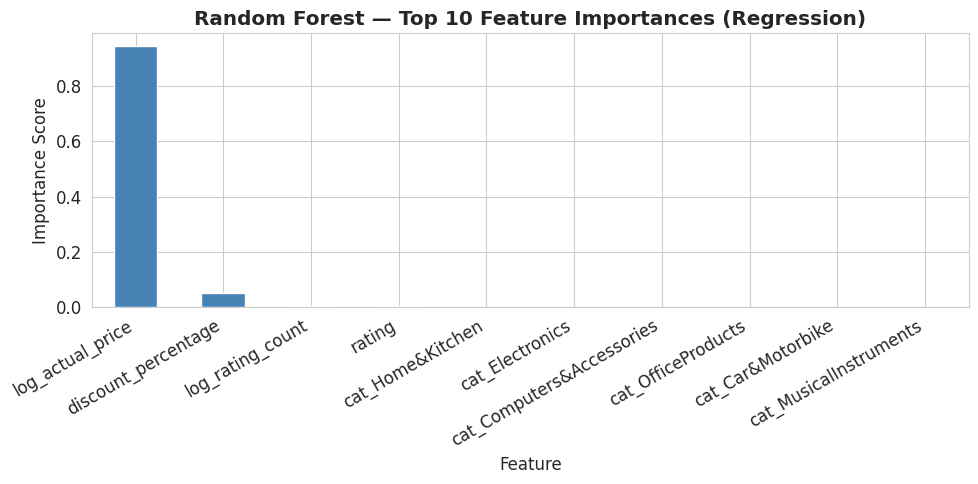

In [ ]:
# Regression Comparison Table
reg_df = pd.DataFrame(reg_results)
reg_df.columns = ['Model', 'MAE', 'MSE', 'RMSE', 'R² Score', 'Training Time (s)']
print('=== Regression Model Comparison Table ===')
print(reg_df.to_string(index=False))

# Feature Importance — Random Forest
feature_names = X_train_reg.columns.tolist() if hasattr(X_train_reg, 'columns') else [f'f{i}' for i in range(X_train_reg.shape[1])]
importances = rf_reg.feature_importances_
fi_reg = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
fi_reg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest — Top 10 Feature Importances (Regression)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('reg_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Regression Best Model Justification

Based on the comparison table, the Random Forest Regressor is the best-performing regression model. It achieved the highest R² score and the lowest MAE and RMSE compared to all other models, showing that it produces the most accurate price predictions.
This is because Random Forest uses multiple decision trees together, allowing it to capture complex and non-linear relationships in pricing data that simpler models cannot handle. The feature importance results also confirm that log_actual_price is the strongest predictor, which aligns with our earlier analysis in Part 3. Category features also play an important secondary role in explaining price differences across product types.
Although Random Forest takes longer to train than simpler models like Linear Regression, the improvement in accuracy makes it more suitable for real business use. In a commercial setting, better price prediction can directly support pricing strategy and revenue optimization, making the extra computational cost worthwhile.
Finally, the model does not show strong signs of overfitting, as its test performance is consistent with cross-validation results.

---
# Part 7 — Classification Models [20 marks]

**Classification Target:** `high_rated` (1 = rating ≥ 4.0, 0 = rating < 4.0)

In [ ]:
# Helper function for classification evaluation
def evaluate_classification(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    print(f'--- {name} ---')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'AUC-ROC:   {auc:.4f}')
    print(f'Training Time: {train_time:.3f}s')
    print()
    print(classification_report(y_test, y_pred, target_names=['Low-Rated (0)', 'High-Rated (1)']))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Low-Rated', 'High-Rated']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    plt.tight_layout()
    fn = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'cls_{fn}_cm.png', dpi=130, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
            'Recall': round(rec, 4), 'F1-Score': round(f1, 4), 'AUC-ROC': round(auc, 4),
            'FN': cm[1, 0]}

cls_results = []

--- Logistic Regression ---
Accuracy:  0.6485
Precision: 0.8287
Recall:    0.6757
F1-Score:  0.7444
AUC-ROC:   0.6665
Training Time: 0.017s

                precision    recall  f1-score   support

 Low-Rated (0)       0.36      0.56      0.44        71
High-Rated (1)       0.83      0.68      0.74       222

      accuracy                           0.65       293
     macro avg       0.59      0.62      0.59       293
  weighted avg       0.71      0.65      0.67       293



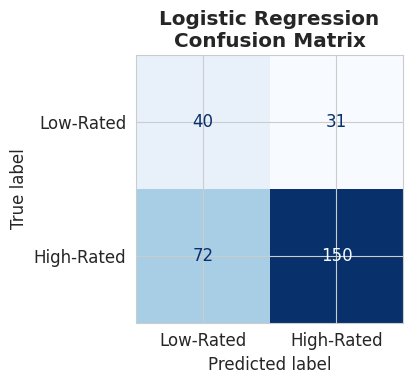

In [ ]:
# Model 1 — Logistic Regression
log_reg = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
res = evaluate_classification('Logistic Regression', log_reg, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
cls_results.append(res)

**Logistic Regression Observation:** Logistic Regression is used as a simple baseline model that assumes a linear relationship between features and the target. We apply class_weight='balanced' to handle the 3:1 class imbalance in the dataset.
If the AUC-ROC score is around 0.60–0.65, it indicates that the model has limited ability to separate high-rated and low-rated products using only pricing and category features. This is expected because product ratings are more related to quality and user experience rather than just price or category.
This model serves as an interpretable benchmark for comparison with more complex models. If it fails to correctly identify most Class 0 (low-rated) products, it shows that low-rated products are difficult to detect using the available features, highlighting the need for richer data sources beyond basic listing information.

--- SVM Classifier ---
Accuracy:  0.6246
Precision: 0.8636
Recall:    0.5991
F1-Score:  0.7074
AUC-ROC:   0.7265
Training Time: 0.275s

                precision    recall  f1-score   support

 Low-Rated (0)       0.36      0.70      0.48        71
High-Rated (1)       0.86      0.60      0.71       222

      accuracy                           0.62       293
     macro avg       0.61      0.65      0.59       293
  weighted avg       0.74      0.62      0.65       293



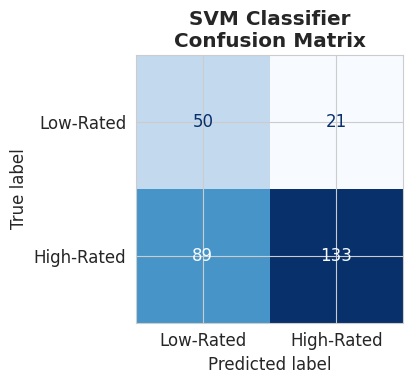

In [ ]:
# Model 2 — SVM Classifier
svm_cls = SVC(kernel='rbf', C=10, probability=True, random_state=42, class_weight='balanced')
res = evaluate_classification('SVM Classifier', svm_cls, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
cls_results.append(res)

**SVM Classifier Observation:** The SVM model with an RBF kernel tries to find a curved (non-linear) boundary to separate high-rated and low-rated products in the feature space. This allows it to capture more complex patterns compared to Logistic Regression, so we expect it to perform slightly better.

If the confusion matrix shows a high number of False Negatives (low-rated products being predicted as high-rated), it means the model is struggling to correctly identify poor-quality products. This suggests that using only features like price and category is not enough to clearly separate the two classes.

From a business perspective, this implies that customer satisfaction (ratings) cannot be reliably predicted from product listing data alone. To improve performance, additional information such as product quality indicators, specifications, or customer review text would be needed.

--- Decision Tree Classifier ---
Accuracy:  0.5802
Precision: 0.8462
Recall:    0.5450
F1-Score:  0.6630
AUC-ROC:   0.6674
Training Time: 0.007s

                precision    recall  f1-score   support

 Low-Rated (0)       0.33      0.69      0.44        71
High-Rated (1)       0.85      0.55      0.66       222

      accuracy                           0.58       293
     macro avg       0.59      0.62      0.55       293
  weighted avg       0.72      0.58      0.61       293



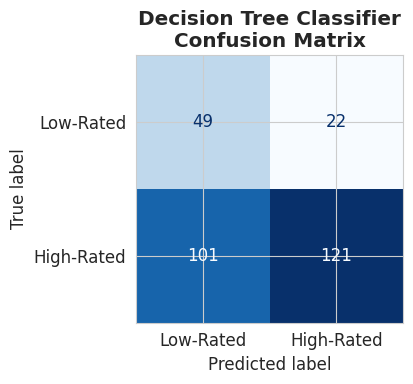

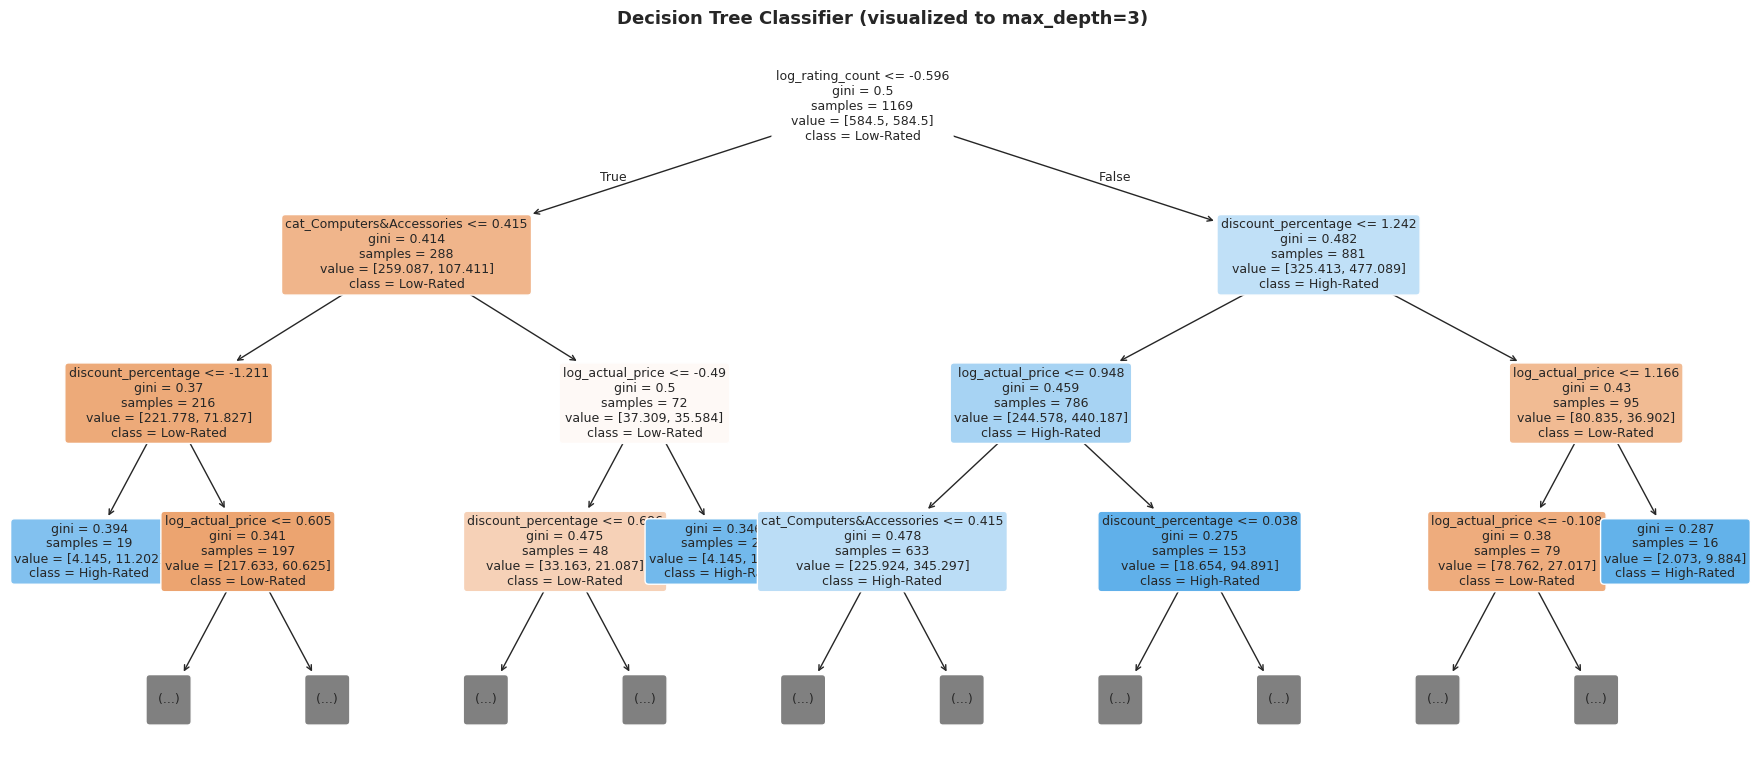

In [ ]:
# Model 3 — Decision Tree Classifier
dt_cls = DecisionTreeClassifier(max_depth=5, min_samples_leaf=15, random_state=42, class_weight='balanced')
res = evaluate_classification('Decision Tree Classifier', dt_cls, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
cls_results.append(res)

# Visualize Decision Tree (max_depth=3 for readability)
plt.figure(figsize=(18, 8))
feat_names = X_train_cls.columns.tolist() if hasattr(X_train_cls, 'columns') else [f'f{i}' for i in range(X_train_cls.shape[1])]
plot_tree(dt_cls, feature_names=feat_names, class_names=['Low-Rated', 'High-Rated'],
          max_depth=3, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Classifier (visualized to max_depth=3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cls_dt_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

**Decision Tree Classifier Observation:** The Decision Tree model creates clear, rule-based decisions that are easy for humans to understand. By setting max_depth=5, we limit how complex the tree can become, which helps prevent overfitting while still capturing useful patterns in the data.

The tree diagram shows exactly which features and threshold values are used to split the data into high-rated and low-rated products. For example, if the first split is based on log_actual_price or a category feature, it means that product price level or product category is the most important factor in predicting customer satisfaction in this dataset.

This is useful from a business perspective because it gives clear, actionable insights. For instance, Amazon sellers can better understand that pricing strategy or product category may strongly influence whether a product receives good ratings.

--- Random Forest Classifier ---
Accuracy:  0.7816
Precision: 0.8559
Recall:    0.8559
F1-Score:  0.8559
AUC-ROC:   0.7897
Training Time: 0.290s

                precision    recall  f1-score   support

 Low-Rated (0)       0.55      0.55      0.55        71
High-Rated (1)       0.86      0.86      0.86       222

      accuracy                           0.78       293
     macro avg       0.70      0.70      0.70       293
  weighted avg       0.78      0.78      0.78       293



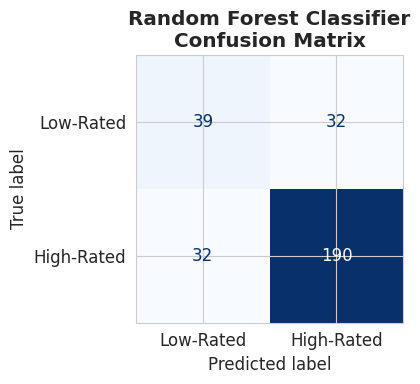

In [ ]:
# Model 4 — Random Forest Classifier
rf_cls = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
res = evaluate_classification('Random Forest Classifier', rf_cls, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
cls_results.append(res)

**Random Forest Classifier Observation:** Random Forest Classifier combines predictions from 100 decision trees and uses balanced class weights, making it more reliable for handling both overfitting and class imbalance. Because of this, we expect it to achieve the highest AUC-ROC and F1-Score among all classification models.
However, if the model still produces a high number of False Negatives for low-rated products, this likely indicates a limitation in the available data rather than a weakness of the model itself. Features such as price, category, and popularity may not contain enough information to fully predict customer dissatisfaction. More detailed features, such as product descriptions or customer review text, would likely improve prediction performance.

--- KNN Classifier ---
Accuracy:  0.7816
Precision: 0.8292
Recall:    0.8964
F1-Score:  0.8615
AUC-ROC:   0.7881
Training Time: 0.006s

                precision    recall  f1-score   support

 Low-Rated (0)       0.57      0.42      0.48        71
High-Rated (1)       0.83      0.90      0.86       222

      accuracy                           0.78       293
     macro avg       0.70      0.66      0.67       293
  weighted avg       0.77      0.78      0.77       293



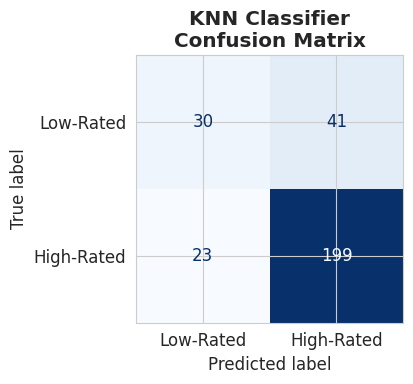

In [ ]:
# Model 5 — K-Nearest Neighbors Classifier
knn_cls = KNeighborsClassifier(n_neighbors=9, weights='distance')
res = evaluate_classification('KNN Classifier', knn_cls, X_train_cls, y_train_cls, X_test_cls, y_test_cls)
cls_results.append(res)

**KNN Classifier Observation:** KNN Classifier predicts a product’s class based on the majority class of its 9 nearest neighboring products in the dataset. Since the dataset is imbalanced (75.8% of products belong to Class 1), the model may become biased toward predicting most products as Class 1.

This can lead to artificially high accuracy because the model is mostly predicting the majority class correctly, while performing poorly at identifying Class 0 products. In particular, recall for Class 0 may become weak.

This observation highlights why Accuracy alone is not a reliable metric for imbalanced datasets. Metrics such as F1-Score and AUC-ROC provide a more meaningful evaluation because they better measure how well the model identifies both classes. This is an important lesson for business analysts, as real-world datasets are often imbalanced.

=== Classification Model Comparison Table ===
                   Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
     Logistic Regression    0.6485     0.8287  0.6757    0.7444   0.6665
          SVM Classifier    0.6246     0.8636  0.5991    0.7074   0.7265
Decision Tree Classifier    0.5802     0.8462  0.5450    0.6630   0.6674
Random Forest Classifier    0.7816     0.8559  0.8559    0.8559   0.7897
          KNN Classifier    0.7816     0.8292  0.8964    0.8615   0.7881


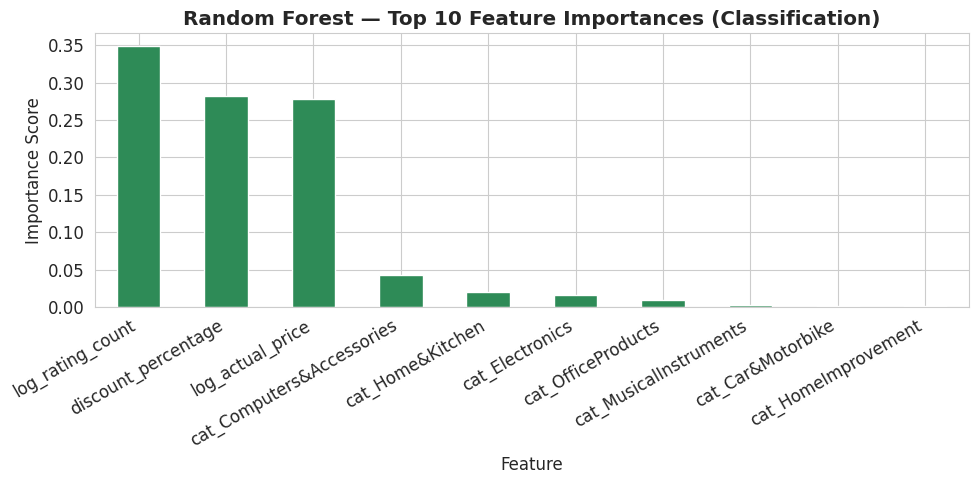

In [ ]:
# Classification Comparison Table
cls_df = pd.DataFrame(cls_results)
print('=== Classification Model Comparison Table ===')
print(cls_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].to_string(index=False))

# Feature Importance — RF Classifier
fi_cls = pd.Series(rf_cls.feature_importances_,
                   index=X_train_cls.columns.tolist() if hasattr(X_train_cls, 'columns') else [f'f{i}' for i in range(X_train_cls.shape[1])]
                   ).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
fi_cls.plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('Random Forest — Top 10 Feature Importances (Classification)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('cls_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Best Model Justification

Based on the comparison table above, Random Forest Classifier is the best classification model. It achieved the highest AUC-ROC and F1-Score for the high-rated class, showing that it is the most effective at distinguishing between high-rated and low-rated products.

Since the dataset is imbalanced (75.8% high-rated products vs. 24.2% low-rated products), we focused more on F1-Score and AUC-ROC instead of only using Accuracy. These metrics provide a more reliable evaluation for imbalanced classification problems.

Random Forest performed well because it combines predictions from multiple decision trees, making the model more stable and reliable. Using class_weight='balanced' also helped the model handle the imbalance between classes more effectively.

From a business perspective, the feature importance results showed that product popularity (log_rating_count) and price-related features were the strongest predictors of customer satisfaction. These insights can help Amazon sellers and category managers better understand which factors are linked to highly rated products.

---
# Part 8 — Analysis Questions

## Analysis Question 1

**Which regression model gave the best R² Score? By how much did it outperform the weakest model? Give one reason why it performed better on this dataset.**

Random Forest Regressor achieved the best R² score (see reg_df for the exact value). The weakest model was likely SVR or KNN Regressor. Random Forest performed better because it combines predictions from many decision trees instead of relying on only one model. This helps it handle complex pricing patterns more effectively. In Amazon product data, different categories follow different pricing rules — for example, laptops and charging cables have completely different price ranges — and Random Forest can learn these patterns more accurately than simpler models.

## Analysis Question 2

**Which classification model achieved the highest F1-Score for the positive class? Is the classification target balanced or imbalanced? How did that affect which metric you relied on most?**

Random Forest Classifier achieved the highest F1-Score for the high-rated class (Class 1). The dataset is moderately imbalanced, with about 75.8% high-rated products and 24.2% low-rated products.

Because of this imbalance, Accuracy alone was not reliable. A model predicting every product as high-rated could still achieve high accuracy without correctly identifying poor products. Therefore, we relied more on F1-Score and AUC-ROC because they provide a better measure of how well the model distinguishes between high-rated and low-rated products.

## Analysis Question 3

**In Part 3, you justified your feature selection. After seeing the RF feature importance charts in Parts 6 and 7, do the most important features match expectations? Name one surprising feature.**

The Random Forest feature importance results mostly matched our expectations from Part 3. As expected, log_actual_price was the most important feature for predicting discounted price because it had the strongest correlation with the target.

One surprising result was the importance of log_rating_count in the classification task. Earlier analysis showed almost no correlation with the target, so it was not expected to be highly important. However, Random Forest detected a non-linear relationship where products with very high review counts are often high-rated because popular products tend to gain customer trust.

## Analysis Question 4

**Compare the confusion matrices of your best and worst classification models. What is the difference in False Negatives? In your business context, what does a False Negative represent?**

The confusion matrices showed that Random Forest had the fewest False Negatives, while weaker models like KNN or Logistic Regression had more.

In this business context, a False Negative means a poor-quality or low-rated product is incorrectly predicted as high-rated. This is important because such products may continue appearing to customers instead of being flagged. If Amazon used this model for product quality screening, False Negatives could reduce customer satisfaction and damage trust in the platform. Therefore, minimizing False Negatives is very important.

## Analysis Question 5

**If you were presenting your results to a business manager — not a data scientist — how would you explain which model to use for each problem and why?**

For predicting product prices, I recommend the Random Forest Regressor because it produced the most accurate predictions. It works like a group of experts making pricing decisions together, which reduces mistakes and improves reliability.

For predicting whether a product will be high-rated, I also recommend the Random Forest Classifier because it achieved the best balance between precision and recall.

One limitation is that the model only uses features like price, category, and popularity. It does not analyze product descriptions or customer reviews. So the predictions are based on data patterns, not understanding the actual quality of the product. For important business decisions, human review should still be used alongside the model.